In [2]:
import import_ipynb
from gaussian_mixture_model import GMM
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sklearn.preprocessing import StandardScaler
from matplotlib.colors import ListedColormap
from skimage.transform import resize
import imageio
username = "manikya.pant"

In [3]:
img1 = mpimg.imread('satellite_1.png')
img2 = mpimg.imread('satellite_2.png')

# Reshape the images to be a list of pixels
# Each pixel is a sample, and its color channels (R, G, B, A) are the features.
def preprocess_image(img):
    if img.dtype == np.float32 or img.dtype == np.float64:
        img = (img * 255).astype(np.uint8)
    else:
        img = img.astype(np.uint8)
    return img


img1 = preprocess_image(img1)
img2 = preprocess_image(img2)

img1_reshaped = img1.reshape(-1, img1.shape[-1])
img2_reshaped = img2.reshape(-1, img2.shape[-1])

# standardizing the data
scaler = StandardScaler()
img1_reshaped = scaler.fit_transform(img1_reshaped)
img2_reshaped = scaler.fit_transform(img2_reshaped)

print("Shape of original image 1:", img1.shape)
print("Shape of reshaped image 1:", img1_reshaped.shape)








Shape of original image 1: (767, 1000, 3)
Shape of reshaped image 1: (767000, 3)


Converged at iteration 75
Fitting complete.
Fitting complete.


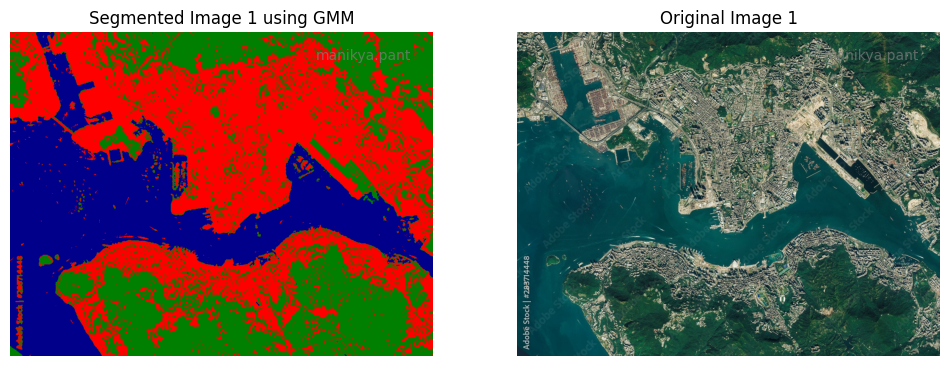

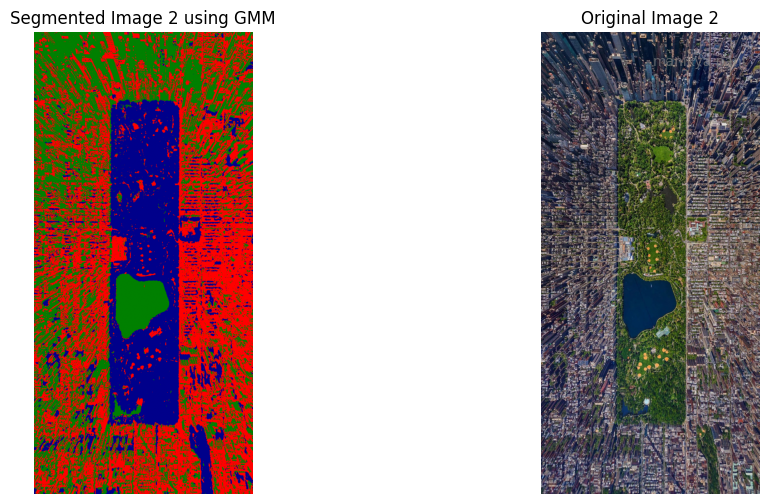

In [5]:
gmm = GMM(3, 100)  # Example: 3 components, 100 iterations

# running GMM on image 1
gmm.fit(img1_reshaped)
labels_img1 = gmm.predict(img1_reshaped)
segmented_img1 = labels_img1.reshape(img1.shape[0], img1.shape[1])

# running GMM on image 2
gmm.fit(img2_reshaped)
labels_img2 = gmm.predict(img2_reshaped)
segmented_img2 = labels_img2.reshape(img2.shape[0], img2.shape[1])


# colors will correspond to labels 0, 1, and 2 respectively.
custom_cmap = ListedColormap(['darkblue', 'green', 'red'])

# displaying the segmented image and the original image for image 1
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(segmented_img1, cmap=custom_cmap)
plt.title('Segmented Image 1 using GMM')
plt.text(
    0.95, 0.95, username,
    ha='right', va='top',
    transform=plt.gca().transAxes,
    fontsize=10, color='gray', alpha=0.7
)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img1)
plt.title('Original Image 1')
plt.axis('off')
plt.text(
    0.95, 0.95, username,
    ha='right', va='top',
    transform=plt.gca().transAxes,
    fontsize=10, color='gray', alpha=0.7
)
plt.show()


# displaying the segmented image and the original image for image 2
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(segmented_img2, cmap=custom_cmap)
plt.title('Segmented Image 2 using GMM')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img2)
plt.title('Original Image 2')
plt.axis('off')

plt.text(
    0.95, 0.95, username,
    ha='right', va='top',
    transform=plt.gca().transAxes,
    fontsize=10, color='gray', alpha=0.7
)
plt.show()


In [7]:
# video generation 

def video_generation(img, img_reshaped, FILENAME='gmm_fitting_video.mp4'):





    frames = []
    logLikelihood =[]
    framerate = 10  #frames per second



    def create_plot_panel(log_likelihoods):
        """Generates an image of the log-likelihood plot."""
        fig, ax = plt.subplots(figsize=(6, 4.5), dpi=100)
        
        iterations = range(1, len(log_likelihoods) + 1)
        ax.plot(iterations, log_likelihoods, marker='o', linestyle='-', color='royalblue')
        
        ax.set_title("Log-Likelihood vs. Iteration")
        ax.set_xlabel("Iteration")
        ax.set_ylabel("Log-Likelihood")
        ax.grid(True)
        fig.tight_layout()
        
        fig.canvas.draw()
        
        rgba_buffer = fig.canvas.buffer_rgba()
        plot_img_rgba = np.asarray(rgba_buffer)
        plot_img = plot_img_rgba[:, :, :3] # Slice off the alpha channel
        
        plt.close(fig)
        
        return plot_img



    gmm.initialize_parameters(img_reshaped)

    for i in range(gmm.max_iter):
        responsibility , log =gmm._e_step(img_reshaped)
        gmm._m_step(img_reshaped,responsibility)
        logLikelihood.append(log)
        
        # assign colours to each based on the weighted average of the 3 colours
        # 0,1,2 correspond to blue, red and green respectively
        # responsibility 0 is the weightage of blue
        # responsibility 1 is the weightage of red
        # responsibility 2 is the weightage of green
    # Your existing code
        panel1= img
        height = panel1.shape[0]
        width = panel1.shape[1]


        colors = responsibility @ np.array([[0, 0, 1], [1, 0, 0], [0, 1, 0]])
        panel2 = (colors.reshape(height, width, 3) * 255).astype(np.uint8)
        panel3 = create_plot_panel(logLikelihood)


        panel2_resized = resize(panel2, (height, width),preserve_range=True).astype(np.uint8)

        panel3_resized = resize(panel3, (height, width),preserve_range=True).astype(np.uint8)


        combined_frame = np.hstack((panel1, panel2_resized, panel3_resized)).astype(np.uint8)

        # Add the final combined frame to your list for the video
        frames.append(combined_frame)


    imageio.mimsave(FILENAME, frames, fps=3)




video_generation(img1, img1_reshaped, FILENAME='gmm_fitting_video_img1.mp4')
video_generation(img2, img2_reshaped, FILENAME='gmm_fitting_video_img2.mp4')

        

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (3000, 767) to (3008, 768) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
[rawvideo @ 0x13816ec0] Stream #0: not enough frames to estimate rate; consider increasing probesize
IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (2265, 1600) to (2272, 1600) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
[rawvideo @ 0x292c8ec0] Stream #0: not enough frames to estimate rate; consider increasing probesize


link to the videos
[link](https://iiithydresearch-my.sharepoint.com/:f:/g/personal/manikya_pant_research_iiit_ac_in/EnI1HATDqz5PoSvU7NiVCl0BYzmHWB8SlV2GVvROd0C6Zg?e=mu36Uo)